# Phase 0 Pilot: L_attn-only Fine-tuning for Orthographic Hallucination

**Goal**: Test whether penalizing diffuse/wandering cross-attention for target text tokens during early denoising (t in {900, 800, 700}) causes measurable OCR improvement.

**Setup**: SDXL + LoRA (rank 16, cross-attention layers only), 100 training steps, 20 DDIM steps for training, 50 for eval.

**What to look for**:
- L_entropy decreasing + NED improving -> mechanism is causal, proceed to full system
- L_entropy decreasing + NED flat -> attention shaping not connected to rendering
- Images become blobs -> beta too high, drop 10x
- NED gets worse -> add L_LDM regularizer

In [ ]:
# Cell 0: Installs (restart runtime after this cell if needed)
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121 -q
!pip install diffusers transformers accelerate peft bitsandbytes -q
!pip install easyocr python-Levenshtein wandb pillow -q
!pip install gdown -q

In [ ]:
# Cell for torchao installation
!pip uninstall torchao -y -q # Uninstall any existing version
!pip install torchao>=0.16.0 -q # Install the required version

In [ ]:
# Cell 1: Imports + Config
import torch
import torch.nn.functional as F
import numpy as np
import json
import time
from pathlib import Path
from PIL import Image
from collections import defaultdict
from Levenshtein import distance as levenshtein_distance

# Check GPU
assert torch.cuda.is_available(), "This notebook requires a GPU runtime"
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# All hyperparameters in one place
CONFIG = {
    # Model
    'base_model': 'stabilityai/stable-diffusion-xl-base-1.0',
    'lora_rank': 16,
    'lora_alpha': 32,
    'lora_targets': ['to_q', 'to_k', 'to_v', 'to_out.0'],

    # Training
    'train_steps': 200,
    'lr': 1e-4,
    'train_ddim_steps': 20,
    'eval_ddim_steps': 50,
    'eval_every': 25,
    'eval_size': 30,
    'seed': 42,

    # Loss
    'beta_entropy': 0.01,          # reduced 10x from 0.1 to prevent collapse,
    'beta_drift': 0.0,            # disabled — caused instability in first run
    'entropy_floor': 6.8,          # hinge loss: stop penalizing below this value,

    # Attention capture
    'window_timesteps': [901, 801, 701],  # DDIM 20-step actual values (off-by-1 from round numbers),
    'capture_layers': ['up_blocks.0'],

    # Generation
    'height': 1024,
    'width': 1024,
    'guidance_scale': 7.5,

    # Paths
    'output_dir': '/content/pilot_output',
}

Path(CONFIG['output_dir']).mkdir(parents=True, exist_ok=True)
print("Config ready.")

GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB
Config ready.


In [ ]:
# Cell 2: Core functions

# -- Tokenizer utils --

def get_target_token_indices(prompt, target_string, tokenizer):
    full_ids = tokenizer.encode(prompt)
    target_ids = tokenizer.encode(target_string, add_special_tokens=False)

    for i in range(len(full_ids) - len(target_ids) + 1):
        if full_ids[i:i+len(target_ids)] == target_ids:
            return list(range(i, i + len(target_ids)))

    # Fallback: lowercase
    full_lower = tokenizer.encode(prompt.lower())
    target_lower = tokenizer.encode(target_string.lower(), add_special_tokens=False)
    for i in range(len(full_lower) - len(target_lower) + 1):
        if full_lower[i:i+len(target_lower)] == target_lower:
            return list(range(i, i + len(target_lower)))

    # Fallback: quoted
    quoted = f'"' + target_string + f'"'
    quoted_ids = tokenizer.encode(quoted, add_special_tokens=False)
    for i in range(len(full_ids) - len(quoted_ids) + 1):
        if full_ids[i:i+len(quoted_ids)] == quoted_ids:
            return list(range(i + 1, i + len(quoted_ids) - 1))

    print(f"  Warning: could not locate '{target_string}' in tokenized prompt")
    return []


# -- Attention capture processor --

from diffusers.models.attention_processor import Attention

class CapturingAttnProcessor:
    def __init__(self, store, layer_name):
        self.store = store
        self.layer_name = layer_name
        self.enabled = False

    def __call__(self, attn, hidden_states, encoder_hidden_states=None,
                 attention_mask=None, **kwargs):
        if encoder_hidden_states is None:
            return self._self_attn(attn, hidden_states, attention_mask)

        B, N, _ = hidden_states.shape
        q = attn.to_q(hidden_states)
        k = attn.to_k(encoder_hidden_states)
        v = attn.to_v(encoder_hidden_states)

        q = attn.head_to_batch_dim(q)
        k = attn.head_to_batch_dim(k)
        v = attn.head_to_batch_dim(v)

        scale = q.shape[-1] ** -0.5
        sim = torch.bmm(q * scale, k.transpose(-1, -2))
        if attention_mask is not None:
            sim = sim + attention_mask
        w = sim.softmax(dim=-1)

        if self.enabled:
            BH, N_s, N_t = w.shape
            H = attn.heads
            w4d = w.reshape(B, H, N_s, N_t)
            self.store.setdefault(self.layer_name, []).append(w4d)

        out = torch.bmm(w, v)
        out = attn.batch_to_head_dim(out)
        out = attn.to_out[0](out)
        out = attn.to_out[1](out)
        return out

    def _self_attn(self, attn, hidden_states, attention_mask):
        q = attn.to_q(hidden_states)
        k = attn.to_k(hidden_states)
        v = attn.to_v(hidden_states)
        q = attn.head_to_batch_dim(q)
        k = attn.head_to_batch_dim(k)
        v = attn.head_to_batch_dim(v)
        sim = torch.bmm(q, k.transpose(-1, -2)) * (q.shape[-1] ** -0.5)
        if attention_mask is not None:
            sim = sim + attention_mask
        w = sim.softmax(dim=-1)
        out = torch.bmm(w, v)
        out = attn.batch_to_head_dim(out)
        out = attn.to_out[0](out)
        out = attn.to_out[1](out)
        return out


def install_capturing_processors(unet, layer_keywords):
    store = {}
    processors = []
    count = 0
    for name, module in unet.named_modules():
        # Check for Attention-like modules (works with or without LoRA wrapping)
        if not hasattr(module, 'set_processor'):
            continue
        if not any(kw in name for kw in layer_keywords):
            continue
        proc = CapturingAttnProcessor(store, layer_name=name)
        module.set_processor(proc)
        processors.append(proc)
        count += 1
        if count <= 3:
            print(f"  Hooked: {name}")
    print(f"Installed capturing processors on {count} attention layers")
    if count == 0:
        print("  WARNING: No layers matched! Listing available attention layers:")
        for n, m in unet.named_modules():
            if hasattr(m, 'set_processor'):
                print(f"    {n}")
    return store, processors


def set_capture_enabled(processors, enabled):
    for p in processors:
        p.enabled = enabled


def clear_store(store):
    store.clear()


# -- L_attn computation (differentiable) --

def get_target_attention_map(store, target_indices):
    all_maps = []
    for layer_name, weight_list in store.items():
        for weights in weight_list:
            w = weights.mean(dim=1)  # avg over heads
            w = w[0, :, target_indices].mean(dim=-1)  # avg target tokens
            n = w.shape[0]
            h = int(n ** 0.5)
            if h * h != n:
                continue
            w = w.reshape(h, h)
            all_maps.append(w)
    if not all_maps:
        return None
    result = torch.stack(all_maps).mean(dim=0)
    result = result / (result.sum() + 1e-8)
    return result


def attention_entropy(A):
    A_flat = A.reshape(-1) + 1e-8
    return -(A_flat * torch.log(A_flat)).sum()


def attention_centroid(A):
    H, W = A.shape
    grid_i = torch.arange(H, device=A.device, dtype=A.dtype)
    grid_j = torch.arange(W, device=A.device, dtype=A.dtype)
    ci = (A.sum(dim=1) * grid_i).sum()
    cj = (A.sum(dim=0) * grid_j).sum()
    return torch.stack([ci, cj])


def compute_L_attn(maps_by_timestep, beta_entropy, beta_drift, window, entropy_floor=None):
    entropy_terms = []
    drift_terms = []
    prev_centroid = None

    for t in sorted(window, reverse=True):
        if t not in maps_by_timestep:
            continue
        A = maps_by_timestep[t]
        H_t = attention_entropy(A)
        if entropy_floor is not None:
            H_t = torch.relu(H_t - entropy_floor)  # hinge: only penalize above floor
        entropy_terms.append(H_t)
        C = attention_centroid(A)
        if prev_centroid is not None:
            drift_terms.append(torch.norm(C - prev_centroid))
        prev_centroid = C.detach()

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    L_entropy = torch.stack(entropy_terms).mean() if entropy_terms else torch.tensor(0., device=device)
    L_drift = torch.stack(drift_terms).mean() if drift_terms else torch.tensor(0., device=device)
    L_attn = beta_entropy * L_entropy + beta_drift * L_drift
    return L_attn, L_entropy, L_drift


# -- OCR evaluation --

def ned(detected, target):
    if len(detected) == 0 and len(target) == 0:
        return 0.0
    return levenshtein_distance(detected.upper(), target.upper()) / max(len(detected), len(target))

def cer(detected, target):
    if len(target) == 0:
        return 0.0 if len(detected) == 0 else 1.0
    return levenshtein_distance(detected.upper(), target.upper()) / len(target)

def ocr_eval_image(image, target, reader):
    results = reader.readtext(np.array(image), detail=1)
    if not results:
        return {'detected': '', 'ned': 1.0, 'cer': 1.0, 'strict': False}

    sorted_results = sorted(results, key=lambda r: (r[0][0][1], r[0][0][0]))
    concat = ''.join(r[1] for r in sorted_results if r[2] >= 0.3)
    candidates = [r[1] for r in sorted_results] + [concat]

    best_ned = 1.0
    best_str = ''
    for c in candidates:
        n = ned(c, target)
        if n < best_ned:
            best_ned = n
            best_str = c

    return {
        'detected': best_str,
        'ned': best_ned,
        'cer': cer(best_str, target),
        'strict': best_str.upper().strip() == target.upper().strip(),
    }

print("Core functions defined.")

Core functions defined.


In [ ]:
# Cell 3: Unit tests (CPU, no model needed)
print("Running attention function tests...")

A_uniform = torch.ones(32, 32) / (32*32)
A_focused = torch.zeros(32, 32); A_focused[16, 16] = 1.0
H_uniform = attention_entropy(A_uniform)
H_focused = attention_entropy(A_focused)
assert H_focused < H_uniform, f"focused ({H_focused:.2f}) should be < uniform ({H_uniform:.2f})"
print(f"  Entropy: uniform={H_uniform:.2f}, focused={H_focused:.2f} OK")

C = attention_centroid(A_uniform)
assert C.shape == torch.Size([2])
assert abs(C[0].item() - 15.5) < 0.1
print(f"  Centroid of uniform: {C.tolist()} (expected ~[15.5, 15.5]) OK")

maps = {}
for t in [900, 800, 700]:
    raw = torch.randn(32*32, requires_grad=True)
    maps[t] = torch.softmax(raw, dim=0).reshape(32, 32)
L, L_H, L_D = compute_L_attn(maps, 0.1, 0.1, [900, 800, 700])
L.backward()
print(f"  L_attn={L.item():.4f}, gradients flow OK")

print("All tests passed!")

Running attention function tests...
  Entropy: uniform=6.93, focused=0.00 OK
  Centroid of uniform: [15.5, 15.5] (expected ~[15.5, 15.5]) OK
  L_attn=0.7329, gradients flow OK
All tests passed!


In [ ]:
# Cell 4: Load SDXL + LoRA + attention hooks

from diffusers import StableDiffusionXLPipeline, DDIMScheduler
from peft import LoraConfig, get_peft_model
# from transformers import BitsAndBytesConfig # Removed for reverting quantization

# bnb_config = BitsAndBytesConfig(
#     load_in_8bit=True
# ) # Removed for reverting quantization

# Correct usage: pass bnb_config directly to quantization_config
pipe = StableDiffusionXLPipeline.from_pretrained(
    CONFIG['base_model'],
    torch_dtype=torch.float16,
    variant='fp16',
    use_safetensors=True # Corrected typo from 'use_safetensons'
    # quantization_config=bnb_config, # Removed for reverting quantization
)
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to('cuda')

lora_config = LoraConfig(
    r=CONFIG['lora_rank'],
    lora_alpha=CONFIG['lora_alpha'],
    target_modules=CONFIG['lora_targets'],
    bias='none',
)
pipe.unet = get_peft_model(pipe.unet, lora_config)
pipe.unet.print_trainable_parameters()

# Print available attention layer names (for debugging)
print("Available attention layers:")
for name, mod in pipe.unet.named_modules():
    if hasattr(mod, 'set_processor'):
        print(f"  {name}")

attn_store, attn_processors = install_capturing_processors(
    pipe.unet, CONFIG['capture_layers']
)

print(f"Model loaded. VRAM: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

trainable params: 23,224,320 || all params: 2,590,688,004 || trainable%: 0.8965
Available attention layers:
  base_model.model.down_blocks.1.attentions.0.transformer_blocks.0.attn1
  base_model.model.down_blocks.1.attentions.0.transformer_blocks.0.attn2
  base_model.model.down_blocks.1.attentions.0.transformer_blocks.1.attn1
  base_model.model.down_blocks.1.attentions.0.transformer_blocks.1.attn2
  base_model.model.down_blocks.1.attentions.1.transformer_blocks.0.attn1
  base_model.model.down_blocks.1.attentions.1.transformer_blocks.0.attn2
  base_model.model.down_blocks.1.attentions.1.transformer_blocks.1.attn1
  base_model.model.down_blocks.1.attentions.1.transformer_blocks.1.attn2
  base_model.model.down_blocks.2.attentions.0.transformer_blocks.0.attn1
  base_model.model.down_blocks.2.attentions.0.transformer_blocks.0.attn2
  base_model.model.down_blocks.2.attentions.0.transformer_blocks.1.attn1
  base_model.model.down_blocks.2.attentions.0.transformer_blocks.1.attn2
  base_model.mod

In [ ]:
# Cell 5: Build prompts + fixed eval set

from google.colab import drive
drive.mount('/content/drive')

from itertools import product as iterproduct

TARGET_STRINGS = {
    'short_common': ['CAT', 'DOG', 'SUN'],
    'medium_common': ['MARKET', 'BRIDGE', 'GARDEN'],
    'long_common': ['STRAWBERRY', 'THUNDERBOLT', 'WATERMELON'],
    'digits': ['2847', '90312', '15503'],
    'mixed_alphanum': ['H2O', 'R2D2', 'B52'],
}

SCENE_TEMPLATES = {
    'blank': 'a plain white sign with the word "{target}" printed clearly on it',
    'simple': 'a wooden storefront sign that clearly says "{target}"',
    'cluttered': 'a neon sign on a busy city street that reads "{target}"',
}

all_prompts = []
for (cat, strings), (scene_name, scene_tmpl) in iterproduct(
    TARGET_STRINGS.items(), SCENE_TEMPLATES.items()
):
    for target in strings:
        scene = scene_tmpl.format(target=target)
        all_prompts.append({
            'prompt': scene,
            'target_string': target,
            'category': cat,
            'scene': scene_name,
            'format': 'quoted',
        })

print(f"Training prompts: {len(all_prompts)}")

# Fixed eval set: 2 per category = 10 total
rng = np.random.default_rng(CONFIG['seed'])
eval_set = []
by_cat = defaultdict(list)
for p in all_prompts:
    by_cat[p['category']].append(p)

for cat in sorted(by_cat.keys()):
    items = by_cat[cat]
    chosen = rng.choice(len(items), size=min(6, len(items)), replace=False)
    for idx in chosen:
        entry = dict(items[idx])
        entry['eval_seed'] = int(rng.integers(10000))
        eval_set.append(entry)

print(f"Eval set: {len(eval_set)} images")
for e in eval_set:
    print(f"  {e['category']:18s} target={e['target_string']:12s} seed={e['eval_seed']}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training prompts: 45
Eval set: 30 images
  digits             target=15503        seed=9756
  digits             target=2847         seed=7357
  digits             target=90312        seed=7611
  digits             target=15503        seed=7174
  digits             target=2847         seed=7860
  digits             target=2847         seed=5132
  long_common        target=STRAWBERRY   seed=5454
  long_common        target=THUNDERBOLT  seed=4434
  long_common        target=THUNDERBOLT  seed=4504
  long_common        target=WATERMELON   seed=2272
  long_common        target=STRAWBERRY   seed=921
  long_common        target=THUNDERBOLT  seed=5545
  medium_common      target=GARDEN       seed=9706
  medium_common      target=GARDEN       seed=4456
  medium_common      target=MARKET       seed=8931
  medium_common      target=GARDEN       seed=6779
  medium_common

In [ ]:
# Cell 6: Training loop

import easyocr
ocr_reader = easyocr.Reader(['en'], gpu=True)
print("EasyOCR ready.")

optimizer = torch.optim.AdamW(
    [p for p in pipe.unet.parameters() if p.requires_grad],
    lr=CONFIG['lr'],
)

window = CONFIG['window_timesteps']
window_set = set(window)
train_log = []
eval_log = []
best_ned = float('inf')
best_step = 0


def run_eval(step_num):
    pipe.unet.eval()
    set_capture_enabled(attn_processors, False)
    results = []
    images = []
    pipe.scheduler.set_timesteps(CONFIG['eval_ddim_steps'])

    with torch.no_grad():
        for item in eval_set:
            gen = torch.Generator('cuda').manual_seed(item['eval_seed'])
            img = pipe(
                item['prompt'],
                num_inference_steps=CONFIG['eval_ddim_steps'],
                guidance_scale=CONFIG['guidance_scale'],
                height=CONFIG['height'], width=CONFIG['width'],
                generator=gen,
            ).images[0]
            metrics = ocr_eval_image(img, item['target_string'], ocr_reader)
            metrics['target'] = item['target_string']
            metrics['category'] = item['category']
            results.append(metrics)
            images.append(img)

    mean_ned = np.mean([r['ned'] for r in results])
    mean_cer = np.mean([r['cer'] for r in results])
    strict_acc = np.mean([r['strict'] for r in results])

    eval_entry = {'step': step_num, 'mean_ned': mean_ned,
                  'mean_cer': mean_cer, 'strict_acc': strict_acc, 'details': results}
    eval_log.append(eval_entry)

    print(f"  === EVAL @ step {step_num} ===")
    print(f"  Mean NED: {mean_ned:.3f} | Mean CER: {mean_cer:.3f} | Strict: {strict_acc:.1%}")
    for r in results:
        status = 'OK' if r['strict'] else 'FAIL'
        print(f"    {r['target']:12s} -> '{r['detected'][:20]:20s}' NED={r['ned']:.2f} [{status}]")

    for i, img in enumerate(images[:4]):
        img.save(f"{CONFIG['output_dir']}/eval_step{step_num}_{i}.png")

    # Early stopping: save best checkpoint
    global best_ned, best_step
    if mean_ned < best_ned:
        best_ned = mean_ned
        best_step = step_num
        best_path = f"{CONFIG['output_dir']}/lora_best"
        pipe.unet.save_pretrained(best_path)
        print(f"  >> New best NED={mean_ned:.3f} at step {step_num}, saved to {best_path}")

    pipe.scheduler.set_timesteps(CONFIG['train_ddim_steps'])
    return eval_entry


# Initial eval (before training)
print("Running initial eval (step 0)...")
pipe.scheduler.set_timesteps(CONFIG['train_ddim_steps'])
train_timesteps = pipe.scheduler.timesteps.tolist()
print(f"Training timesteps ({len(train_timesteps)}): {train_timesteps}")
run_eval(0)

# Training
print(f"\nStarting training for {CONFIG['train_steps']} steps...")
t_start = time.time()

for step in range(1, CONFIG['train_steps'] + 1):
    pipe.unet.train()
    optimizer.zero_grad()

    idx = step % len(all_prompts)
    item = all_prompts[idx]
    prompt = item['prompt']
    target_string = item['target_string']

    token_indices = get_target_token_indices(prompt, target_string, pipe.tokenizer)
    if not token_indices:
        continue

    with torch.no_grad():
        prompt_embeds, neg_embeds, pooled, neg_pooled = pipe.encode_prompt(
            prompt=prompt, device='cuda',
            num_images_per_prompt=1,
            do_classifier_free_guidance=False,
        )
        time_ids = torch.tensor(
            [[CONFIG['height'], CONFIG['width'], 0, 0, CONFIG['height'], CONFIG['width']]],
            device='cuda', dtype=torch.float16,
        )

    gen = torch.Generator('cuda').manual_seed(CONFIG['seed'] + step)
    latents = torch.randn(
        (1, pipe.unet.config.in_channels, CONFIG['height'] // 8, CONFIG['width'] // 8),
        generator=gen, device='cuda', dtype=torch.float16,
    ) * pipe.scheduler.init_noise_sigma

    maps_by_timestep = {}
    pipe.scheduler.set_timesteps(CONFIG['train_ddim_steps'])

    for t in pipe.scheduler.timesteps:
        t_val = int(t.item())
        clear_store(attn_store)

        in_window = t_val in window_set
        set_capture_enabled(attn_processors, in_window)

        with torch.set_grad_enabled(in_window):
            noise_pred = pipe.unet(
                latents, t,
                encoder_hidden_states=prompt_embeds,
                added_cond_kwargs={'text_embeds': pooled, 'time_ids': time_ids},
            ).sample

            if in_window and attn_store:
                A = get_target_attention_map(attn_store, token_indices)
                if A is not None:
                    maps_by_timestep[t_val] = A

        with torch.no_grad():
            latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

    if not maps_by_timestep:
        print(f"Step {step}: no maps captured, skipping")
        continue

    L_attn, L_entropy, L_drift = compute_L_attn(
        maps_by_timestep, CONFIG['beta_entropy'], CONFIG['beta_drift'], window,
        entropy_floor=CONFIG.get('entropy_floor'),
    )

    L_attn.backward()
    torch.nn.utils.clip_grad_norm_(pipe.unet.parameters(), max_norm=1.0)
    optimizer.step()

    entry = {'step': step, 'L_attn': L_attn.item(),
             'L_entropy': L_entropy.item(), 'L_drift': L_drift.item(),
             'target': target_string}
    train_log.append(entry)

    elapsed = time.time() - t_start
    if step % 10 == 0 or step == 1:
        eta = elapsed / step * (CONFIG['train_steps'] - step)
        print(f"Step {step:3d}/{CONFIG['train_steps']} | "
              f"L_attn={L_attn.item():.4f} L_H={L_entropy.item():.4f} L_D={L_drift.item():.4f} | "
              f"{elapsed/60:.1f}m elapsed, ~{eta/60:.0f}m remaining")

    if step % CONFIG['eval_every'] == 0:
        run_eval(step)

print(f"\nTraining complete in {(time.time() - t_start)/60:.1f} minutes")
run_eval(CONFIG['train_steps'])

with open(f"{CONFIG['output_dir']}/train_log.json", 'w') as f:
    json.dump(train_log, f, indent=2)
with open(f"{CONFIG['output_dir']}/eval_log.json", 'w') as f:
    json.dump(eval_log, f, indent=2)
print(f"Logs saved to {CONFIG['output_dir']}")
print(f"\nBest checkpoint: step {best_step} with NED={best_ned:.3f}")

EasyOCR ready.
Running initial eval (step 0)...
Training timesteps (20): [951, 901, 851, 801, 751, 701, 651, 601, 551, 501, 451, 401, 351, 301, 251, 201, 151, 101, 51, 1]


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  === EVAL @ step 200 ===
  Mean NED: 0.378 | Mean CER: 0.425 | Strict: 20.0%
    15503        -> '153                 ' NED=0.40 [FAIL]
    2847         -> '2471                ' NED=0.50 [FAIL]
    90312        -> '0                   ' NED=0.80 [FAIL]
    15503        -> '35                  ' NED=0.80 [FAIL]
    2847         -> '487                 ' NED=0.50 [FAIL]
    2847         -> '2457                ' NED=0.50 [FAIL]
    STRAWBERRY   -> 'Strawberry          ' NED=0.00 [OK]
    THUNDERBOLT  -> 'JTIUNERBIDIRL       ' NED=0.62 [FAIL]
    THUNDERBOLT  -> 'THUNDERBOLIL        ' NED=0.23 [FAIL]
    WATERMELON   -> 'WATIERMILON         ' NED=0.18 [FAIL]
    STRAWBERRY   -> 'STRAWBEERY          ' NED=0.10 [FAIL]
    THUNDERBOLT  -> 'THUNIBERBEBOLLT     ' NED=0.33 [FAIL]
    GARDEN       -> 'GARDEN              ' NED=0.00 [OK]
    GARDEN       -> 'GARDEN              ' NED=0.00 [OK]
    MARKET       -> 'markeet             ' NED=0.14 [FAIL]
    GARDEN       -> 'GARDEN              ' 

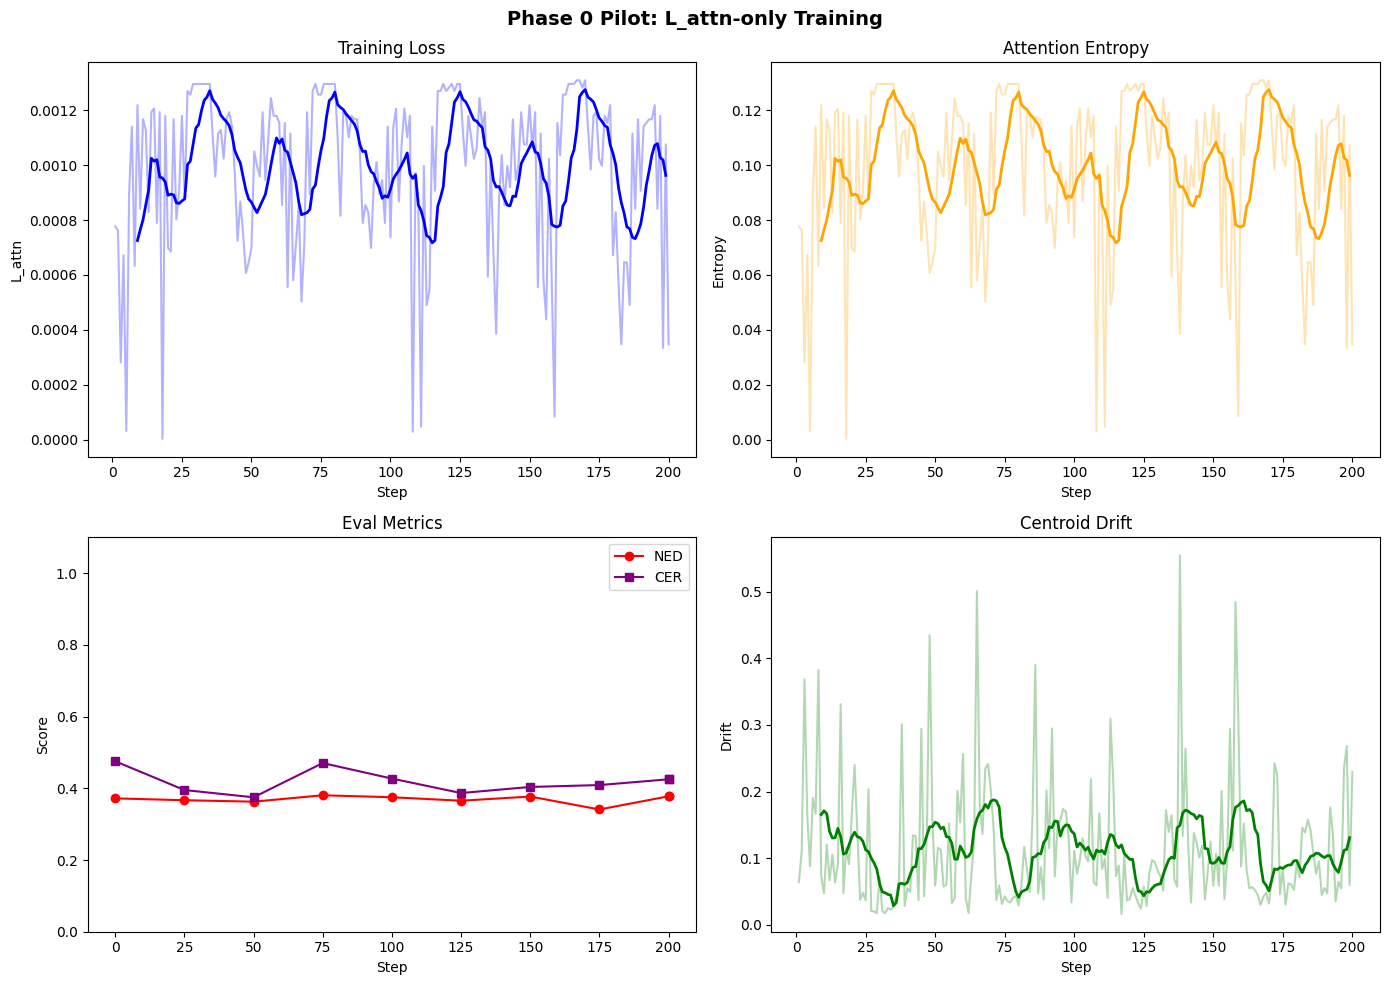

PILOT SUMMARY
  NED:    0.372 -> 0.378 (delta = +0.006)
  CER:    0.475 -> 0.425 (delta = -0.050)
  Strict: 20.0% -> 20.0%

  -> NED roughly flat. Attention shaping may not be connected to rendering.
    Consider: expanding capture layers, or falling back to OCR-only DDPO.


In [ ]:
# Cell 7: Results visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Phase 0 Pilot: L_attn-only Training', fontsize=14, fontweight='bold')

steps = [e['step'] for e in train_log]
ws = min(10, len(train_log))

# L_attn
ax = axes[0, 0]
ax.plot(steps, [e['L_attn'] for e in train_log], alpha=0.3, color='blue')
if ws > 1:
    sm = np.convolve([e['L_attn'] for e in train_log], np.ones(ws)/ws, mode='valid')
    ax.plot(range(ws-1, len(train_log)), sm, color='blue', linewidth=2)
ax.set_xlabel('Step'); ax.set_ylabel('L_attn'); ax.set_title('Training Loss')

# Entropy
ax = axes[0, 1]
ax.plot(steps, [e['L_entropy'] for e in train_log], alpha=0.3, color='orange')
if ws > 1:
    sm = np.convolve([e['L_entropy'] for e in train_log], np.ones(ws)/ws, mode='valid')
    ax.plot(range(ws-1, len(train_log)), sm, color='orange', linewidth=2)
ax.set_xlabel('Step'); ax.set_ylabel('Entropy'); ax.set_title('Attention Entropy')

# Eval NED/CER
ax = axes[1, 0]
ev_steps = [e['step'] for e in eval_log]
ax.plot(ev_steps, [e['mean_ned'] for e in eval_log], 'o-', color='red', label='NED')
ax.plot(ev_steps, [e['mean_cer'] for e in eval_log], 's-', color='purple', label='CER')
ax.set_xlabel('Step'); ax.set_ylabel('Score'); ax.set_title('Eval Metrics')
ax.legend(); ax.set_ylim(0, 1.1)

# Drift
ax = axes[1, 1]
ax.plot(steps, [e['L_drift'] for e in train_log], alpha=0.3, color='green')
if ws > 1:
    sm = np.convolve([e['L_drift'] for e in train_log], np.ones(ws)/ws, mode='valid')
    ax.plot(range(ws-1, len(train_log)), sm, color='green', linewidth=2)
ax.set_xlabel('Step'); ax.set_ylabel('Drift'); ax.set_title('Centroid Drift')

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/pilot_results.png", dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("=" * 60)
print("PILOT SUMMARY")
print("=" * 60)
initial = eval_log[0]
final = eval_log[-1]
delta_ned = final['mean_ned'] - initial['mean_ned']
delta_cer = final['mean_cer'] - initial['mean_cer']
print(f"  NED:    {initial['mean_ned']:.3f} -> {final['mean_ned']:.3f} (delta = {delta_ned:+.3f})")
print(f"  CER:    {initial['mean_cer']:.3f} -> {final['mean_cer']:.3f} (delta = {delta_cer:+.3f})")
print(f"  Strict: {initial['strict_acc']:.1%} -> {final['strict_acc']:.1%}")

if delta_ned < -0.02:
    print("\n  -> NED improved. Attention mechanism appears causal. Proceed to full system.")
elif delta_ned > 0.05:
    print("\n  -> NED got worse. Try adding L_LDM regularizer or reducing beta.")
else:
    print("\n  -> NED roughly flat. Attention shaping may not be connected to rendering.")
    print("    Consider: expanding capture layers, or falling back to OCR-only DDPO.")

In [ ]:
# Cell 8: Save LoRA weights (if results look promising)
import shutil

save_path = f"{CONFIG['output_dir']}/lora_pilot"
pipe.unet.save_pretrained(save_path)
print(f"LoRA weights saved to {save_path}")

drive_save = '/content/drive/MyDrive/ortho_pilot_lora'
shutil.copytree(save_path, drive_save, dirs_exist_ok=True)
print(f"Copied to {drive_save}")

LoRA weights saved to /content/pilot_output/lora_pilot
Copied to /content/drive/MyDrive/ortho_pilot_lora
